In [1]:
"Musfikur Rahman Mahin"

'Musfikur Rahman Mahin'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

DATA_URL = "https://raw.githubusercontent.com/quirk21/Project422/refs/heads/main/Tree_Sterility_Dataset.csv"

df = pd.read_csv(DATA_URL)
print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (2783, 24)


,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,...,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,...,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,...,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,...,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,...,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,...,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN


##  Exploratory Data Analysis

### Comparison of sterile and non sterile trees


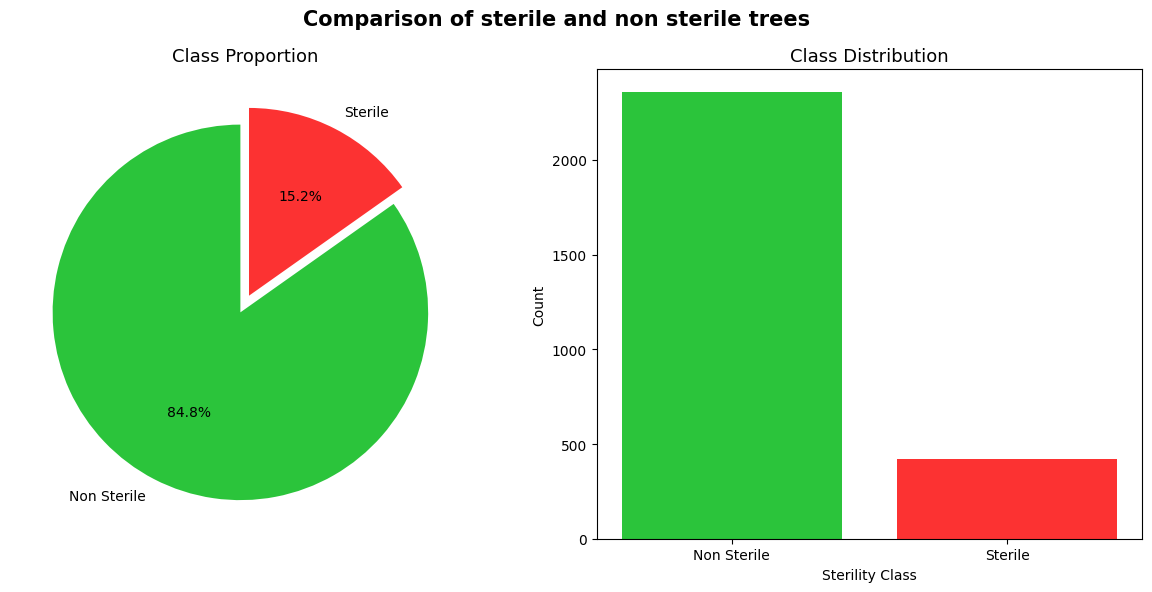

In [4]:
tree = df.copy()

class_counts = tree['Sterile'].value_counts() # gives count of all the value present in Sterile column

figure, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(class_counts.values, colors=['#2bc43b', '#fc3232'],
        labels=['Non Sterile','Sterile'], startangle=90,
        explode=[0.05]*len(class_counts), autopct='%1.1f%%')
axes[0].set_title('Class Proportion', fontsize=13)


axes[1].bar(['Non Sterile','Sterile'], class_counts.values,
            color=['#2bc43b', '#fc3232'])
axes[1].set_title('Class Distribution', fontsize=13)
axes[1].set_xlabel('Sterility Class')
axes[1].set_ylabel('Count')


plt.suptitle('Comparison of sterile and non sterile trees', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation of all the features

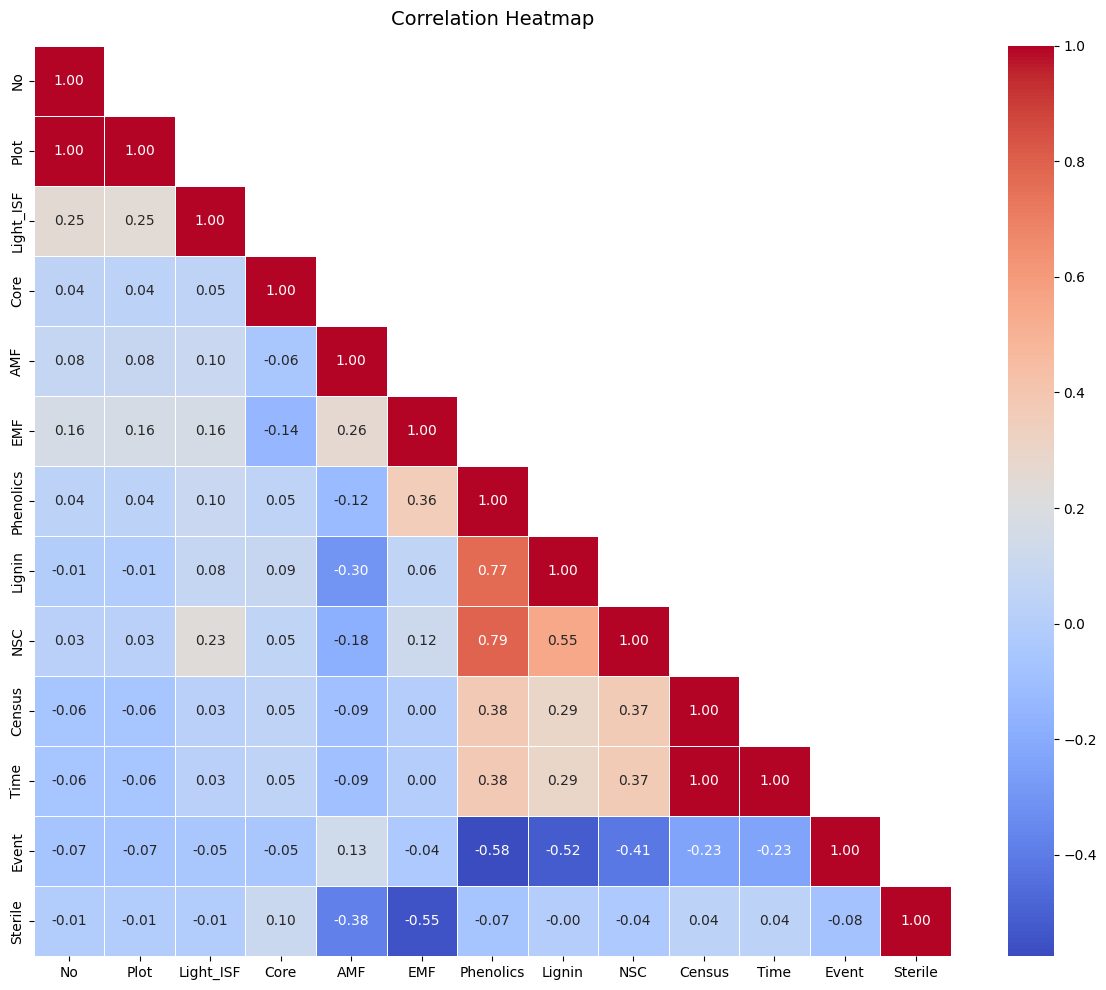

In [ ]:
# only taking columns with numbers
tree = df.select_dtypes(include=[np.number])
# making 1/0 value for Sterile column and making a new column
tree['Sterile'] = (df['Sterile'] == 'Sterile').astype(int)
corr_matrix = tree.corr()

plt.figure(figsize=(12,10))

# as correlation matrix is symmetric we are taking only lower part
# mask is a upper triangular matrix same dimension as corr_matrix
# in seaborn false value in mask will be shown
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask ,annot=True,
            cmap='coolwarm', fmt=".2f",
            linewidths=0.5)


plt.title('Correlation Heatmap', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Data Splitting


In [ ]:
tree = df.copy()

##Selecting numerical features
numerical_data = tree.select_dtypes(include='number')

#append the features of numerical_data to list
numerical_features=numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:')
print(numerical_features)

print()

#Selecting categoricalfeatures
categorical_data=tree.select_dtypes(include= 'object')

#append the features of categorical_data to list
categorical_features=categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:')
print(categorical_features)

There are 12 numerical features:
['No', 'Plot', 'Light_ISF', 'Core', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time', 'Event']

There are 12 categorical features:
['Subplot', 'Species', 'Light_Cat', 'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco', 'PlantDate', 'Harvest', 'Alive']


### Descriptive Analysis

In [ ]:
numerical_data.describe().T

,count,mean,std,min,25%,50%,75%,max
No,2783.0,3914.513834,2253.515063,3.000,1971.000,3932.000,5879.000,7772.000
Plot,2783.0,9.561624,5.203659,1.000,5.000,10.000,14.000,18.000
Light_ISF,2783.0,0.085707,0.025638,0.032,0.066,0.082,0.100,0.161
Core,2783.0,2016.648940,0.477387,2016.000,2016.000,2017.000,2017.000,2017.000
AMF,2783.0,20.553069,12.309587,0.000,13.400,18.000,24.445,100.000
EMF,1283.0,26.476750,16.636890,0.000,13.780,27.720,35.710,87.500
Phenolics,2783.0,1.933105,1.969842,-1.350,0.170,0.750,3.780,6.100
Lignin,2783.0,15.759792,6.779607,2.230,10.355,14.040,21.115,32.770
NSC,2783.0,14.219641,4.298271,4.300,11.605,12.660,17.275,29.450
Census,2783.0,15.282070,9.166555,4.000,7.000,13.000,18.000,33.000


In [ ]:
categorical_data.describe().T

,count,unique,top,freq
Subplot,2783,5,A,701
Species,2783,4,Acer saccharum,751
Light_Cat,2783,3,Med,1474
Soil,2783,7,Sterile,423
Adult,2783,36,I,90
Sterile,2783,2,Non-Sterile,2360
Conspecific,2783,3,Heterospecific,1974
Myco,2783,2,AMF,1500
SoilMyco,2783,3,AMF,1186
PlantDate,2783,19,6/7/18,340


In [ ]:
numerical_data.var()

,0
No,5.078330e+06
Plot,2.707807e+01
Light_ISF,6.572914e-04
Core,2.278988e-01
AMF,1.515259e+02
EMF,2.767861e+02
Phenolics,3.880277e+00
Lignin,4.596307e+01
NSC,1.847513e+01
Census,8.402573e+01


In [ ]:
numerical_data.skew()

,0
No,-0.013436
Plot,-0.012063
Light_ISF,0.658495
Core,-0.624428
AMF,1.530073
EMF,0.504768
Phenolics,0.325592
Lignin,0.141701
NSC,0.569887
Census,1.033268


### Feature Distributions by Sterility Class

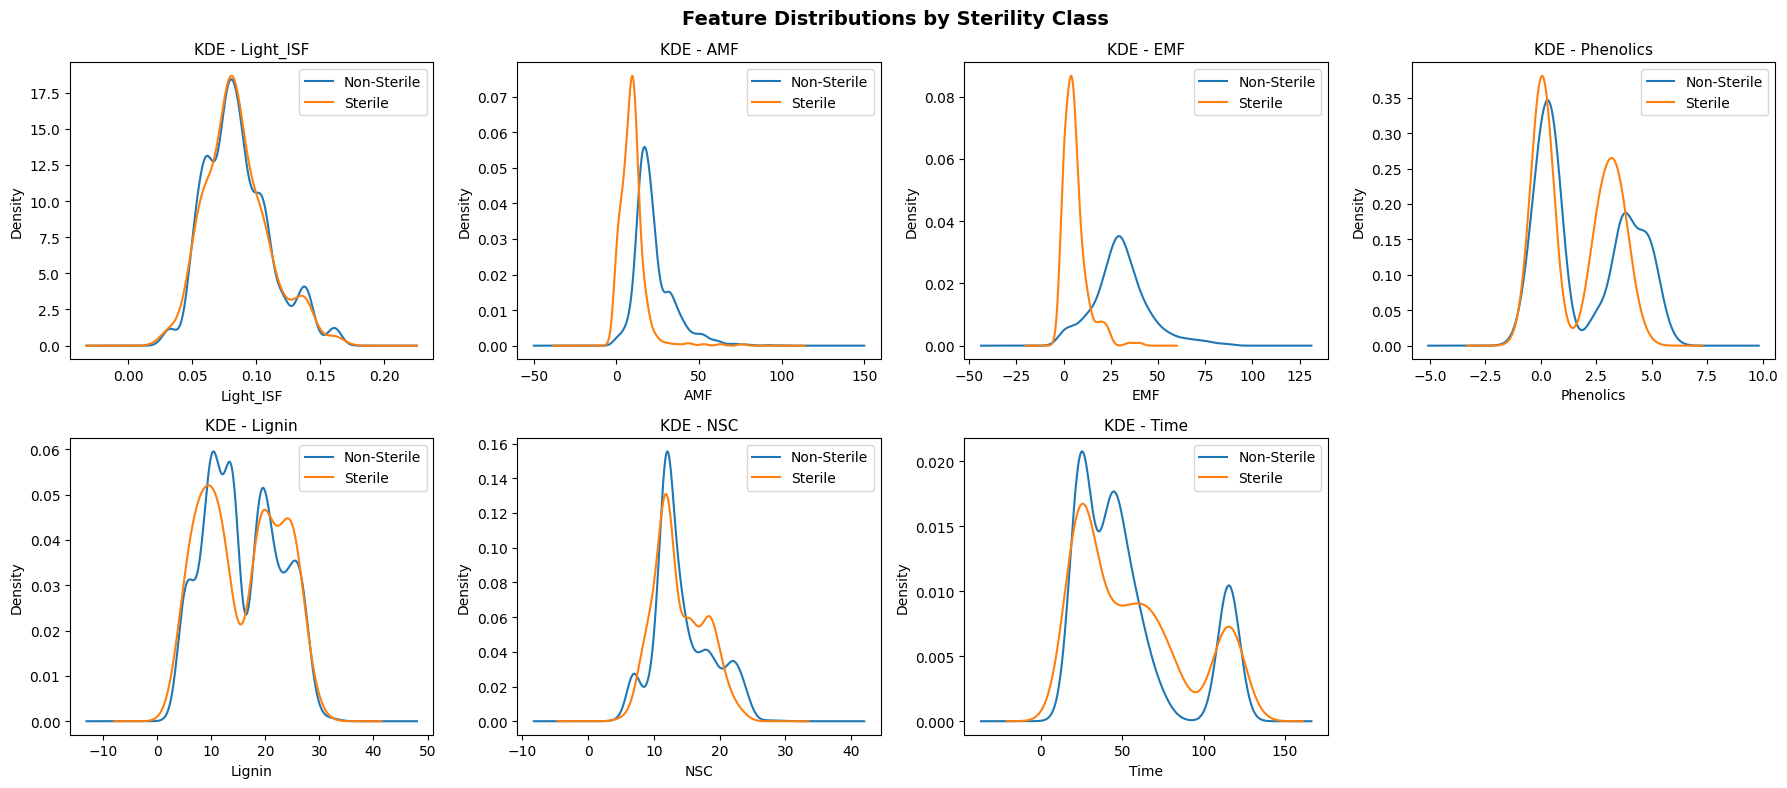

In [ ]:
# A Kernel Density Estimate (KDE) plot is a method for visualizing
# the distribution of observations in a dataset, similar to a histogram
# but using a smooth, continuous curve

num_features = ['Light_ISF', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Time']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()  # converts the grids into a 1D list

for i, feat in enumerate(num_features):
    df.groupby('Sterile')[feat].plot.kde(ax=axes[i], legend=True)  # splits data into groups (e.g., Sterile = 0 and Sterile = 1)
    axes[i].set_title(f'KDE - {feat}', fontsize=11)                # , selects one feature and plot KDE
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Density')

axes[-1].axis('off') # removing the last grid
plt.suptitle('Feature Distributions by Sterility Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Boxplot

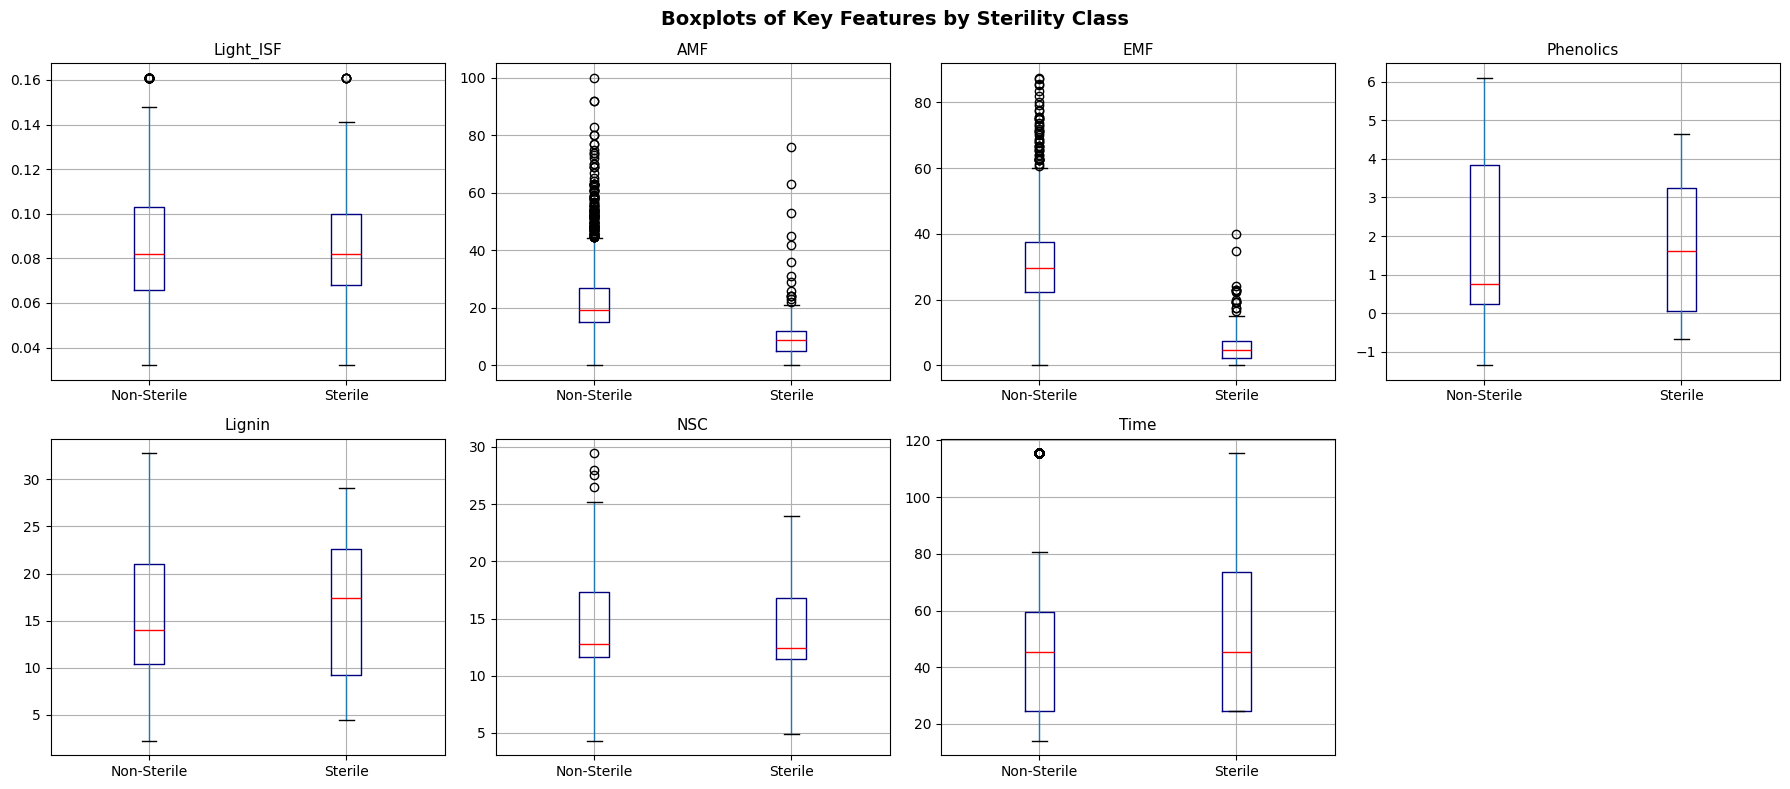

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    df.boxplot(column=feat, by='Sterile', ax=axes[i],
               boxprops=dict(color='navy'), medianprops=dict(color='red'))
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('')

axes[-1].axis('off')
plt.suptitle('Boxplots of Key Features by Sterility Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Catagorical feature comparison in histogram

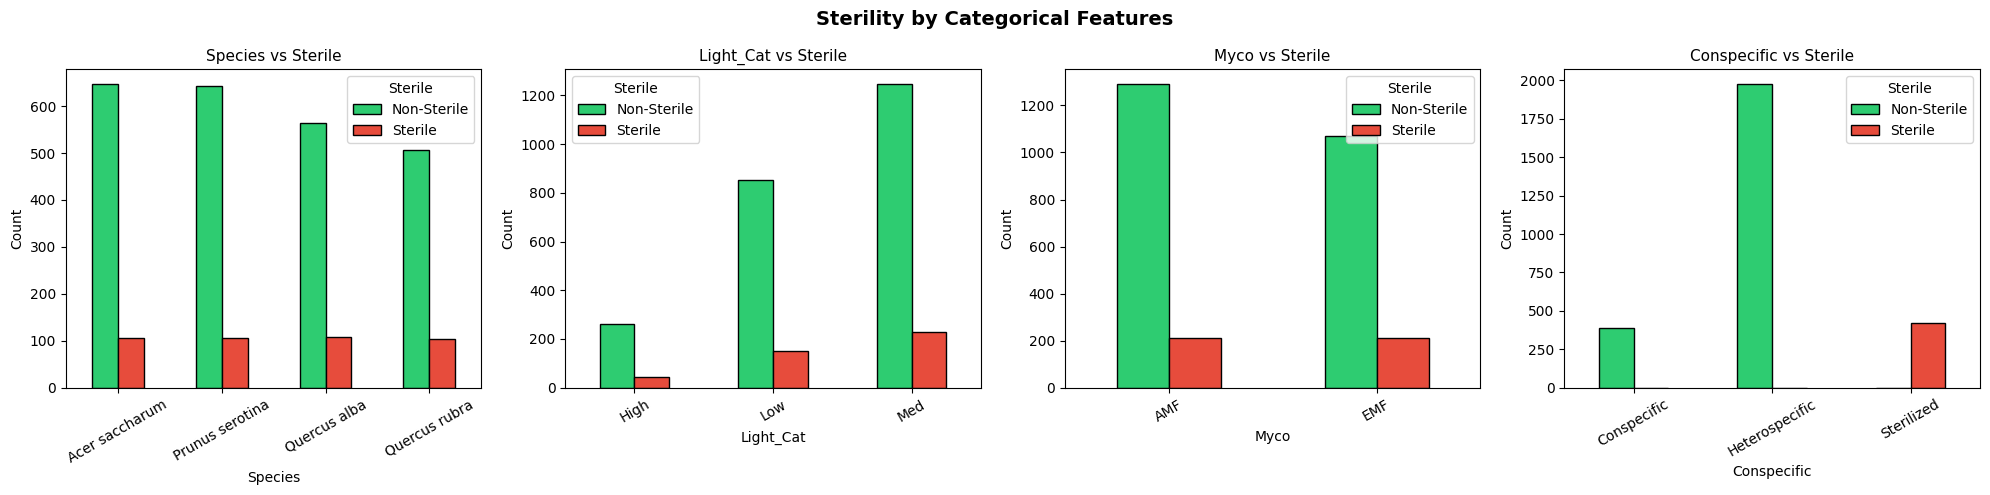

In [ ]:
cat_plot_cols = ['Species', 'Light_Cat', 'Myco', 'Conspecific']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(cat_plot_cols):
    ct = pd.crosstab(df[col], df['Sterile'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[i].set_title(f'{col} vs Sterile', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Sterility by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Data PreProcessing

In [ ]:
# check missing values
print("Data types:",", ".join(df.dtypes.unique().astype(str)))
print(f"Missing values {df.isnull().sum().sum()}")
print("=" * 25)
print()


missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

print('Missing value summary:')
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))
print("=" * 25)
print()

df.info()

Data types: int64, object, float64
Missing values 5872

Missing value summary:
         Missing Count  Missing %
Alive             2292      82.36
Harvest           2079      74.70
EMF               1500      53.90
Event                1       0.04

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           2783 non-null   int64  
 1   Plot         2783 non-null   int64  
 2   Subplot      2783 non-null   object 
 3   Species      2783 non-null   object 
 4   Light_ISF    2783 non-null   float64
 5   Light_Cat    2783 non-null   object 
 6   Core         2783 non-null   int64  
 7   Soil         2783 non-null   object 
 8   Adult        2783 non-null   object 
 9   Sterile      2783 non-null   object 
 10  Conspecific  2783 non-null   object 
 11  Myco         2783 non-null   object 
 12  SoilMyco     2783 non-null   object 
 13  PlantDat

In [ ]:
df_clean = df.copy()

# Drop high-missingness / redundant ID-type columns
# Dropping Conspecific, Soil, SoilMyco as it has some output as Sterile
# Dropping Core as it seems like not related to sterility
drop_cols = ['No', 'Plot', 'Subplot', 'Adult', 'SoilMyco', 'Soil', 'PlantDate', 'Core', 'Conspecific', 'Harvest', 'Alive', 'Census']
df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns], inplace=True)
print(f'Dropped columns: {drop_cols}')
print("Remaining columns:", list(df_clean.columns))
print(f'Shape after dropping: {df_clean.shape}')

# Impute remaining numeric NaN with median
for col in df_clean.select_dtypes(include=[np.number]).columns:
    if df_clean[col].isnull().sum() > 0:        # marks missing values (NaN) as True
        med = df_clean[col].median()
        df_clean[col].fillna(med, inplace=True) # Replaces all NaN values in that column with the median
        print(f'  Imputed "{col}" with median = {med:.3f}')


print(f'\n Missing values: {df_clean.isnull().sum().sum()}')

Dropped columns: ['No', 'Plot', 'Subplot', 'Adult', 'SoilMyco', 'Soil', 'PlantDate', 'Core', 'Conspecific', 'Harvest', 'Alive', 'Census']
Remaining columns: ['Species', 'Light_ISF', 'Light_Cat', 'Sterile', 'Myco', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Time', 'Event']
Shape after dropping: (2783, 12)
  Imputed "EMF" with median = 27.720
  Imputed "Event" with median = 1.000

 Missing values: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_enc = df_clean.copy()

# Label encode target
le_target = LabelEncoder()
df_enc['Sterile'] = le_target.fit_transform(df_enc['Sterile'])
print('Target encoding:', dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# Binary label encode
binary_cols = ['Myco', 'SoilMyco']
le = LabelEncoder()
for col in binary_cols:
    if col in df_enc.columns:
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))
        print(f'Label encoded: {col}')

# One-hot encode nominal categorical columns
ohe_cols = ['Species', 'Light_Cat']
ohe_cols = [c for c in ohe_cols if c in df_enc.columns]

df_enc = pd.get_dummies(df_enc, columns=ohe_cols, drop_first=True)
print('\nOne-Hot encoded: ',', '.join(ohe_cols))
print('Shape after encoding: ',df_enc.shape)
df_enc.head()

Target encoding: {'Non-Sterile': np.int64(0), 'Sterile': np.int64(1)}
Label encoded: Myco

One-Hot encoded:  Species, Light_Cat
Shape after encoding:  (2783, 15)


,Light_ISF,Sterile,Myco,AMF,EMF,Phenolics,Lignin,NSC,Time,Event,Species_Prunus serotina,Species_Quercus alba,Species_Quercus rubra,Light_Cat_Low,Light_Cat_Med
0,0.106,0,0,22.00,27.72,-0.56,13.86,12.15,14.0,1.0,False,False,False,False,True
1,0.106,0,1,15.82,31.07,5.19,20.52,19.29,115.5,0.0,False,True,False,False,True
2,0.106,0,1,24.45,28.19,3.36,24.74,15.01,63.0,1.0,False,False,True,False,True
3,0.080,0,0,22.23,27.72,-0.71,14.29,12.36,14.0,1.0,False,False,False,False,True
4,0.060,0,0,21.15,27.72,-0.58,10.85,11.20,14.0,1.0,False,False,False,True,False


### Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

tree = df_enc.copy()
# removing sterile
x = tree.drop(columns=['Sterile']).astype(float)
# only taking sterile
y = tree['Sterile']

# 80/20 stratified sampling
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.20, random_state=42, stratify=y)

# scalling after splitting as the test set is supposed to be completely unseen future data.
X_train = pd.DataFrame(scaler.fit_transform(x_train), columns=x.columns)
# Standardization (mean 0, variance 1)
# The scaler applies the exact same rules it learned from the training
# data. It does not learn any new math from x_test, so no fit
X_test  = pd.DataFrame(scaler.transform(x_test), columns=x.columns)

print('Splitting the Train / Test data to 80% / 20%')
print(f'Training set : {X_train.shape[0]} samples  ({X_train.shape[0]/len(x)*100:.1f}%)')
print(f'Test set     : {X_test.shape[0]}  samples  ({X_test.shape[0]/len(x)*100:.1f}%)')

print()
print('Class distribution for training:')
print(y_train.value_counts())
print('Class distribution for testing:')
print(y_test.value_counts())

Splitting the Train / Test data to 80% / 20%
Training set : 2226 samples  (80.0%)
Test set     : 557  samples  (20.0%)

Class distribution for training:
Sterile
0    1888
1     338
Name: count, dtype: int64
Class distribution for testing:
Sterile
0    472
1     85
Name: count, dtype: int64


## Model Training

### All Imports for Model Testing

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                            confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn import tree as dtree

result = {}

### KNN



In [ ]:
k_score = []
for k in range(1, 21):
    knn_temp = KNeighborsClassifier(n_neighbors=k) # temporary model using k neighbors
    knn_temp.fit(x_train, y_train)                 # tmodel studying the practice data
    k_score.append(accuracy_score(y_test, knn_temp.predict(x_test))) # finding the accuracy

best_k, best_acc = k_score.index(max(k_score)) + 1, max(k_score)
print(f"Best k = {best_k}, Accuracy = {best_acc:.4f}")

knn_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance') # building the final model
knn_model.fit(X_train, y_train) # train the model
y_pred_knn = knn_model.predict(X_test) # predicting output
y_prob_knn = knn_model.predict_proba(X_test)[:, 1] #  slices out only column 1 from pred of being 0/1

result['KNN'] = {
    'accuracy' : accuracy_score(y_test, y_pred_knn),
    'precision': precision_score(y_test, y_pred_knn, zero_division=0), # zero_div = avoids errors when no positive predictions exist
    'recall'   : recall_score(y_test, y_pred_knn, zero_division=0), # out of actual positives, how many were found
    'f1'       : f1_score(y_test, y_pred_knn, zero_division=0), # balance between precision and recall
    'auc'      : roc_auc_score(y_test, y_prob_knn), # measures how well the model separates classes
    'y_pred'   : y_pred_knn, # prediction
    'y_prob'   : y_prob_knn # probability for prediction
}

print()
print('KNN Metrics')
for m, v in result['KNN'].items():
    if isinstance(v, float): print(f'{m:10s}: {v:.4f}')  # instance only selects numeric metric values

Best k = 4, Accuracy = 0.9605

KNN Metrics
accuracy  : 0.9515
precision : 0.8537
recall    : 0.8235
f1        : 0.8383
auc       : 0.9503


### Decision Tree

In [ ]:
dt_model = DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced') # handles imbalanced data, when one class appears more than the other
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)
y_prob_dt = dt_model.predict_proba(x_test)[:, 1]

# plt.figure(figsize=(20, 10))  # make it big enough to see
# dtree.plot_tree(dt_model, filled=True, fontsize=8)
# plt.show()

print()
result['Decision Tree'] = {
    'accuracy' : accuracy_score(y_test, y_pred_dt),
    'precision': precision_score(y_test, y_pred_dt, zero_division=0),
    'recall'   : recall_score(y_test, y_pred_dt, zero_division=0),
    'f1'       : f1_score(y_test, y_pred_dt, zero_division=0),
    'auc'      : roc_auc_score(y_test, y_prob_dt),
    'y_pred'   : y_pred_dt,
    'y_prob'   : y_prob_dt
}
print('Decision Tree Metrics:')
for m, v in result['Decision Tree'].items():
    if isinstance(v, float): print(f'{m:10s}: {v:.4f}')


Decision Tree Metrics:
accuracy  : 0.9587
precision : 0.8298
recall    : 0.9176
f1        : 0.8715
auc       : 0.9457


### Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

result['Logistic Regression'] = {
    'accuracy' : accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'recall'   : recall_score(y_test, y_pred_lr, zero_division=0),
    'f1'       : f1_score(y_test, y_pred_lr, zero_division=0),
    'auc'      : roc_auc_score(y_test, y_prob_lr),
    'y_pred'   : y_pred_lr,
    'y_prob'   : y_prob_lr
}

print()
print('Logistic Regression Metrics:')
for m, v in result['Logistic Regression'].items():
    if isinstance(v, float): print(f'{m:10s}: {v:.4f}')


Logistic Regression Metrics:
accuracy  : 0.9120
precision : 0.6475
recall    : 0.9294
f1        : 0.7633
auc       : 0.9559


### Naive Bayes

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train) # gaussianNB doesn't try and adjust, it is calculating mean, variances
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

result['Naive Bayes'] = {
    'accuracy' : accuracy_score(y_test, y_pred_nb),
    'precision': precision_score(y_test, y_pred_nb, zero_division=0),
    'recall'   : recall_score(y_test, y_pred_nb, zero_division=0),
    'f1'       : f1_score(y_test, y_pred_nb, zero_division=0),
    'auc'      : roc_auc_score(y_test, y_prob_nb),
    'y_pred'   : y_pred_nb,
    'y_prob'   : y_prob_nb
}

print()
print('Naive Bayes Metrics:')
for m, v in result['Naive Bayes'].items():
    if isinstance(v, float): print(f'{m:10s}: {v:.4f}')


Naive Bayes Metrics:
accuracy  : 0.8941
precision : 0.7500
recall    : 0.4588
f1        : 0.5693
auc       : 0.9246


### Neural Network

In [ ]:
# weights are updated using adam optimizer
# activation funciton is relu

nn_model = MLPClassifier( hidden_layer_sizes=(128, 64, 32), activation='relu',
                        solver='adam', max_iter=500, random_state=42,
                        early_stopping=True, validation_fraction=0.1, n_iter_no_change=20)

nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)
y_prob_nn = nn_model.predict_proba(X_test)[:, 1]

print()
result['Neural Network'] = {
    'accuracy' : accuracy_score(y_test, y_pred_nn),
    'precision': precision_score(y_test, y_pred_nn, zero_division=0),
    'recall'   : recall_score(y_test, y_pred_nn, zero_division=0),
    'f1'       : f1_score(y_test, y_pred_nn, zero_division=0),
    'auc'      : roc_auc_score(y_test, y_prob_nn),
    'y_pred'   : y_pred_nn,
    'y_prob'   : y_prob_nn
}
print('Neural Network Metrics:')
for m, v in result['Neural Network'].items():
    if isinstance(v, float): print(f'{m:10s}: {v:.4f}')


Neural Network Metrics:
accuracy  : 0.9677
precision : 0.9351
recall    : 0.8471
f1        : 0.8889
auc       : 0.9874


### Kmeans clustering

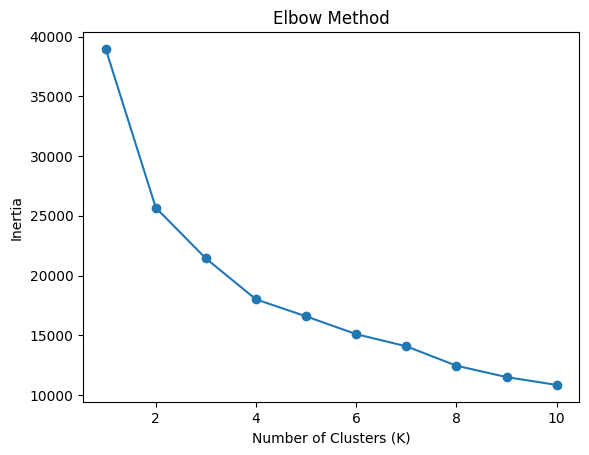

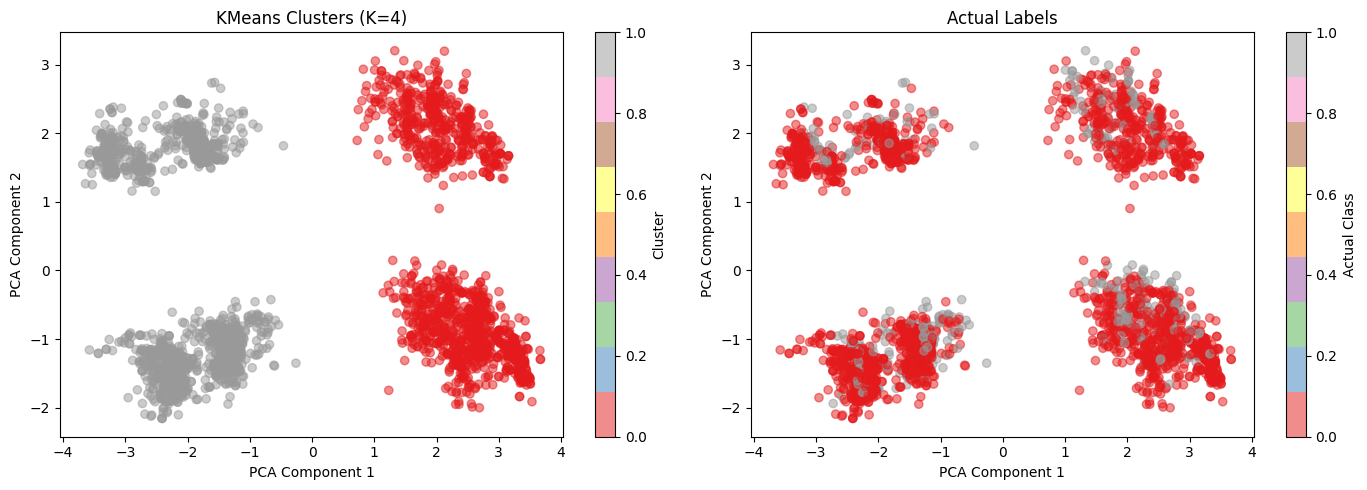

In [ ]:
# all data will be used here
x_all_scaled = pd.DataFrame(StandardScaler().fit_transform(x), columns=x.columns)

# Elbow method
inertia_list = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(x_all_scaled)  # no y_train cause unsupervised
    inertia_list.append(km.inertia_)

plt.plot(k_range, inertia_list, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()



# best k = 2
km_final = KMeans(n_clusters=2, random_state=42, n_init='auto')
cluster_labels = km_final.fit_predict(x_all_scaled)

# visualise with PCA
pca = PCA(n_components=2) # compress all feature to 2d
x_pca = pca.fit_transform(x_all_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KMeans clusters
scatter1 = axes[0].scatter(x_pca[:, 0], x_pca[:, 1], c=cluster_labels, cmap='Set1', alpha=0.5)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')
axes[0].set_title(f'KMeans Clusters (K={best_k})')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')

# Actual labels
scatter2 = axes[1].scatter(x_pca[:, 0], x_pca[:, 1], c=y, cmap='Set1', alpha=0.5)
plt.colorbar(scatter2, ax=axes[1], label='Actual Class')
axes[1].set_title('Actual Labels')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

## Model Comparison

In [ ]:
# summary

summary_data = {}

for model, m in result.items():
    summary_data[model] = {
        'Accuracy' : round(m['accuracy'],  4),
        'Precision': round(m['precision'], 4),
        'Recall'   : round(m['recall'],    4),
        'F1 Score' : round(m['f1'],        4),
        'AUC'      : round(m['auc'],       4),
    }

summary = pd.DataFrame(summary_data).T # .T making it easier to read

print('Model Comparison Summary:')
print(summary.to_string())

Model Comparison Summary:
                     Accuracy  Precision  Recall  F1 Score     AUC
KNN                    0.9515     0.8537  0.8235    0.8383  0.9503
Decision Tree          0.9587     0.8298  0.9176    0.8715  0.9457
Logistic Regression    0.9120     0.6475  0.9294    0.7633  0.9559
Naive Bayes            0.8941     0.7500  0.4588    0.5693  0.9246
Neural Network         0.9677     0.9351  0.8471    0.8889  0.9874


### Accuracy Barchat

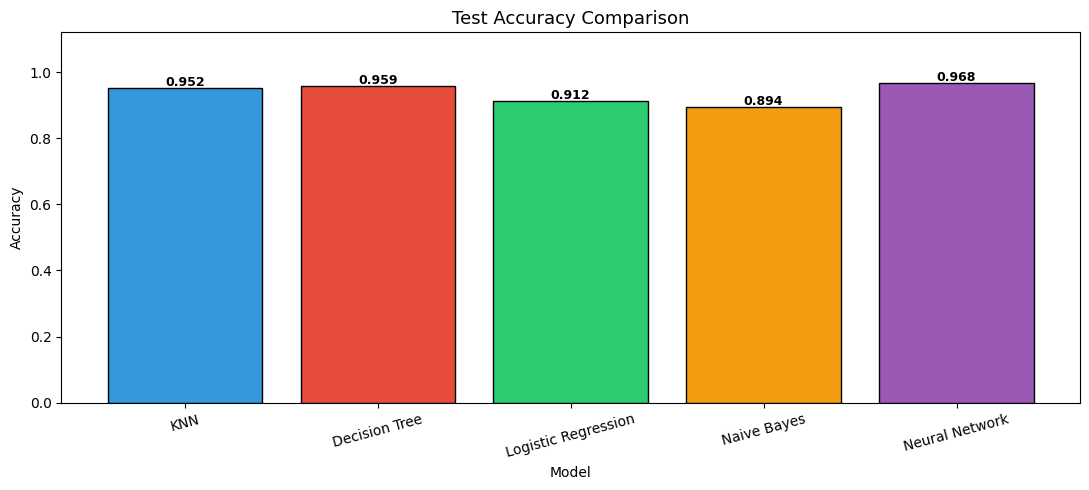

In [ ]:
palette_models = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

plt.figure(figsize=(11, 5))
bars = plt.bar(summary.index, summary['Accuracy'],
               color=palette_models[:len(summary)], edgecolor='black')
for bar, val in zip(bars, summary['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, # label each bar with its accuracy value
            f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)

plt.ylim(0, 1.12)
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.title('Test Accuracy Comparison', fontsize=13)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Precision & Recall Comparison

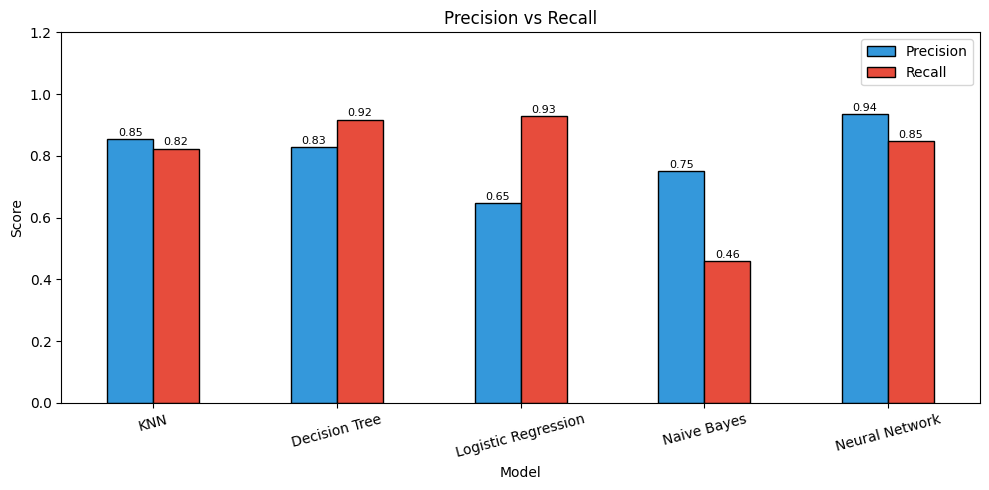

In [ ]:
ax = summary[['Precision', 'Recall']].plot(kind='bar', figsize=(10, 5),
                                       color=['#3498db', '#e74c3c'],
                                       edgecolor='black')

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=8)

plt.title('Precision vs Recall')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.ylim(0, 1.2)
plt.legend()
plt.tight_layout()
plt.show()

### Confusion Matrix

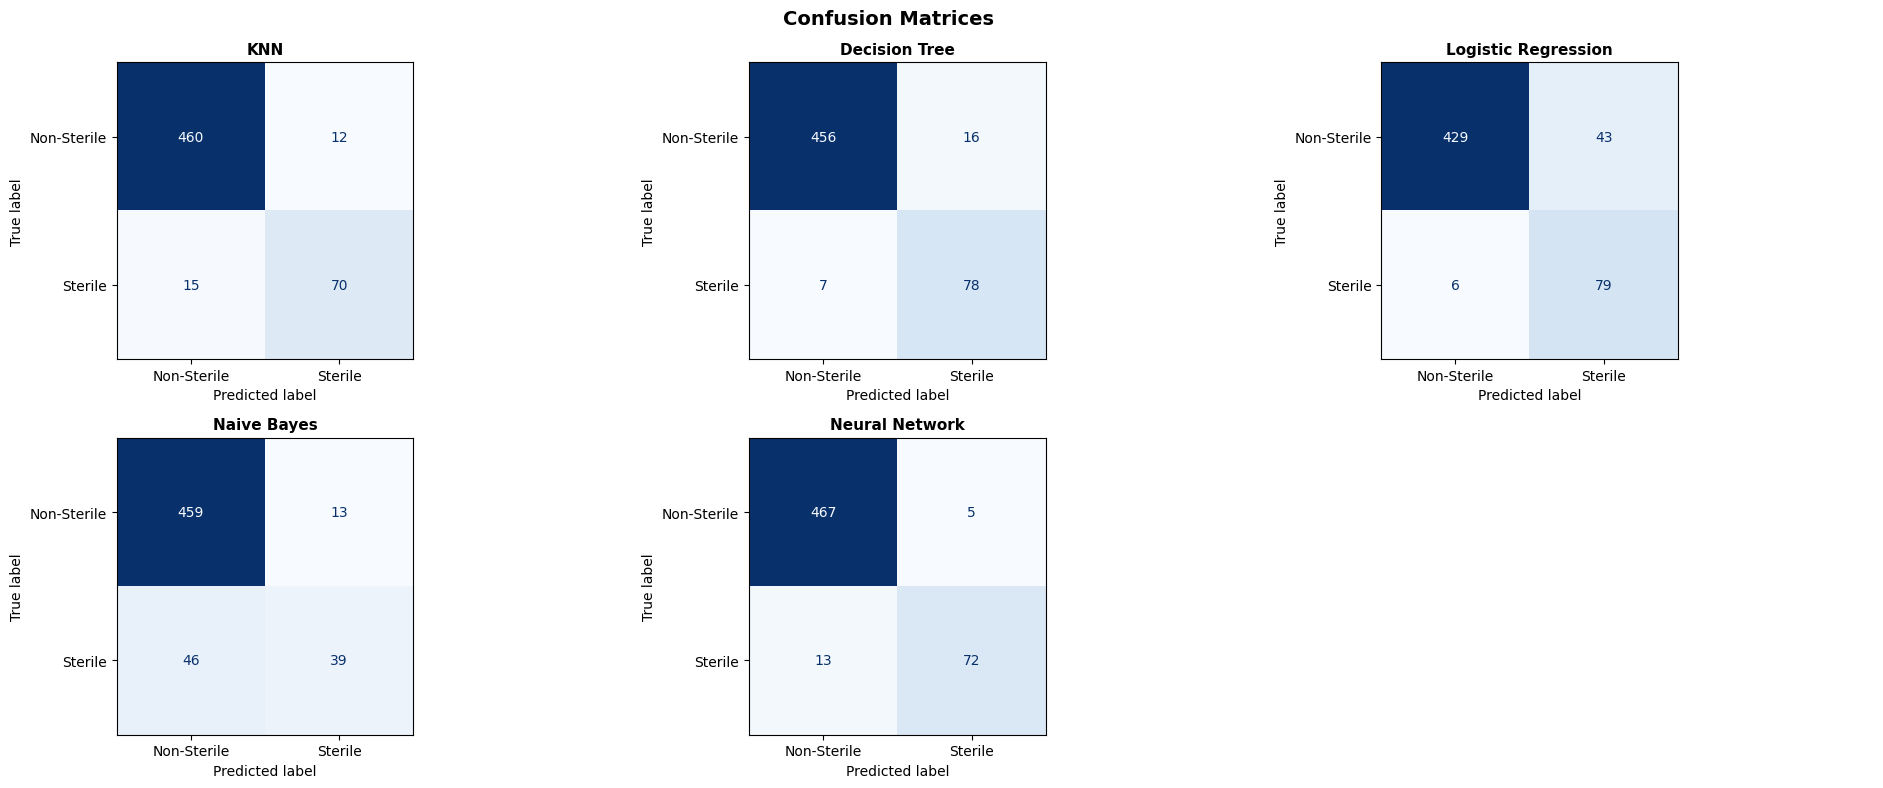

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 8))
axes = axes.flatten()
axes[-1].axis('off')

for i, (model_name, m) in enumerate(result.items()):
    cm = confusion_matrix(y_test, m['y_pred'])
    temp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
    temp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(model_name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### AUC score and ROC curve

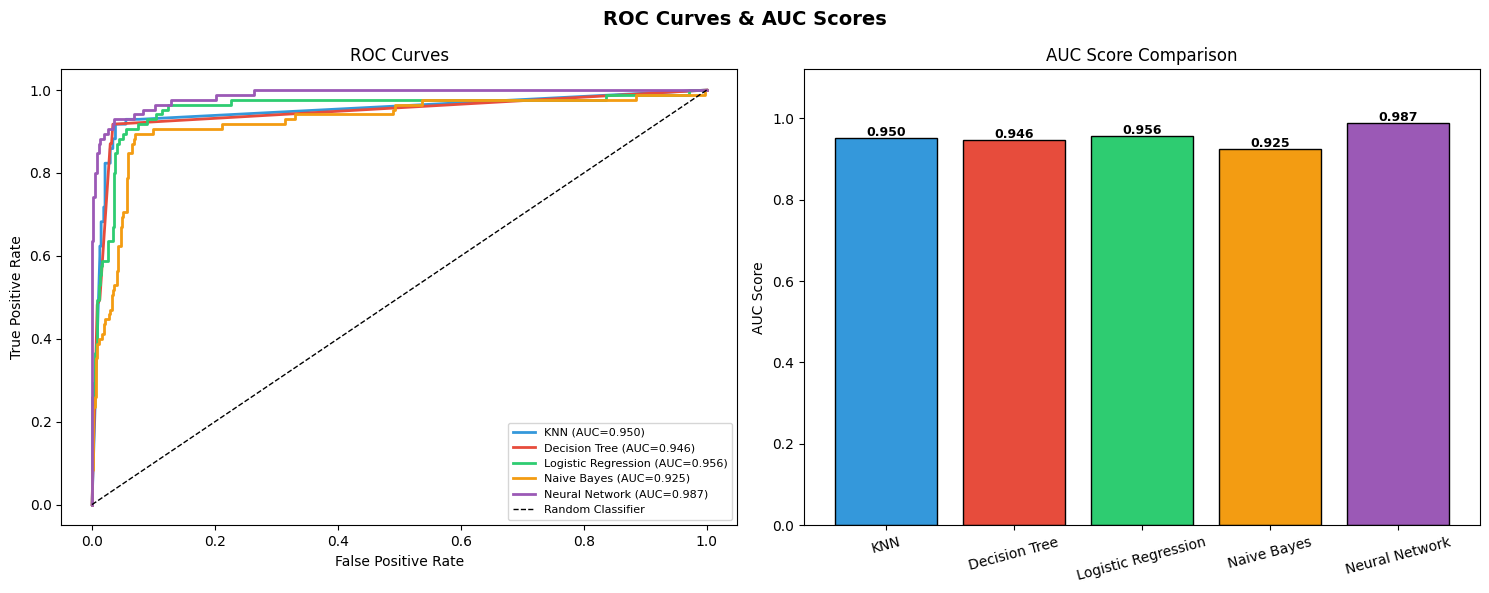

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC curves
for (model_name, m), color in zip(result.items(), palette_models):
    fpr, tpr, _ = roc_curve(y_test, m['y_prob']) # false positive rate and true positive rate
    axes[0].plot(fpr, tpr, label=f"{model_name} (AUC={m['auc']:.3f})", color=color, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=12)
axes[0].legend(fontsize=8)

# AUC bar chart
auc_bars = axes[1].bar(summary.index, summary['AUC'],
                       color=palette_models[:len(summary)], edgecolor='black')
for bar, val in zip(auc_bars, summary['AUC']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold', fontsize=9)
axes[1].set_ylim(0, 1.12)
axes[1].set_ylabel('AUC Score')
axes[1].set_title('AUC Score Comparison', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('ROC Curves & AUC Scores', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Final Comparison

In [ ]:
print(summary.to_string())
print()
print()

best_acc = summary['Accuracy'].idxmax()
best_auc = summary['AUC'].idxmax()
best_f1  = summary['F1 Score'].idxmax()

print(f'Best Accuracy  : {best_acc:<10s} ({summary.loc[best_acc, "Accuracy"]:.4f})')
print(f'Best AUC Score : {best_auc:<10s} ({summary.loc[best_auc, "AUC"]:.4f})')
print(f'Best F1 Score  : {best_f1:<10s} ({summary.loc[best_f1, "F1 Score"]:.4f})')

                     Accuracy  Precision  Recall  F1 Score     AUC
KNN                    0.9515     0.8537  0.8235    0.8383  0.9503
Decision Tree          0.9587     0.8298  0.9176    0.8715  0.9457
Logistic Regression    0.9120     0.6475  0.9294    0.7633  0.9559
Naive Bayes            0.8941     0.7500  0.4588    0.5693  0.9246
Neural Network         0.9677     0.9351  0.8471    0.8889  0.9874


Best Accuracy  : Neural Network (0.9677)
Best AUC Score : Neural Network (0.9874)
Best F1 Score  : Neural Network (0.8889)
